In [9]:
import pandas as pd
import os
import re

# ── 1. CONFIGURAZIONE ─────────────────────────────────────────────────────────

DATA_FOLDER = r"C:\Users\Administrator\Desktop\PROGETTO_L2"

MACRO_AREA = {
    "PIEMONTE":   "Nord",
    "LIGURIA":    "Nord",
    "LOMBARDIA":  "Nord",
    "TRENTINO":   "Nord",
    "VENETO":     "Nord",
    "FRIULI":     "Nord",
    "EMILIA":     "Nord",
    "TOSCANA":    "Centro",
    "UMBRIA":     "Centro",
    "MARCHE":     "Centro",
    "LAZIO":      "Centro",
    "ABBRUZZO":   "Sud",
    "ABRUZZO":    "Sud",
    "CAMPANIA":   "Sud",
    "PUGLIA":     "Sud",
    "BASILICATA": "Sud",
    "CALABRIA":   "Sud",
    "SICILIA":    "Isole",
    "SARDEGNA":   "Isole",
}

# ── 2. FUNZIONI ───────────────────────────────────────────────────────────────

def parse_valore(val_str):
    if val_str is None:
        return None
    val_str = val_str.strip().strip('"')
    if val_str in ("-", "", "n.d.", "nd", "N.D."):
        return None
    val_str = val_str.replace(",", ".")
    try:
        return float(val_str)
    except ValueError:
        return None


def estrai_regione_dal_nome(filename):
    nome = os.path.basename(filename).lower()
    nome = nome.replace("datialmalaurea", "").replace("datialmaurea", "")
    nome = re.sub(r"[_(].*", "", nome)
    return nome.upper().strip()


def get_parte(parti, idx):
    return parti[idx].strip() if len(parti) > idx else None


def leggi_csv_almalaurea(filepath):
    righe_raw = []
    with open(filepath, encoding="latin-1") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parti = [p.strip().strip('"') for p in line.split(";")]
            righe_raw.append(parti)

    r = {}
    sezione = "popolazione"

    for parti in righe_raw:
        chiave = parti[0].strip() if len(parti) > 0 else ""
        valore = parti[1].strip() if len(parti) > 1 else ""
        cl = chiave.lower()
        v  = parse_valore(valore)

        # ── Aggiorna sezione ──
        if "2a. formazione di secondo livello" in cl:
            sezione = "magistrale"; continue
        elif "2b. formazione post-laurea" in cl:
            sezione = "postlaurea"; continue
        elif "3. condizione occupazionale" in cl:
            sezione = "occupazione"; continue
        elif "4. ingresso nel mercato" in cl:
            sezione = "ingresso"; continue
        elif "5. caratteristiche dell" in cl and "attuale lavoro" in cl:
            sezione = "lavoro"; continue
        elif "6. caratteristiche dell" in cl and "impresa" in cl:
            sezione = "impresa"; continue
        elif "7. retribuzione" in cl:
            sezione = "retribuzione"; continue
        elif "8. utilizzo" in cl:
            sezione = "utilizzo"; continue
        elif "9. efficacia" in cl:
            sezione = "efficacia"; continue

        # ── SEZIONE 1: Popolazione ──
        if sezione == "popolazione":
            if "numero di laureati" in cl and "n_laureati" not in r:
                r["n_laureati"] = v
            elif "numero di intervistati" in cl:
                r["n_intervistati"] = v
            elif "tasso di risposta sul totale" in cl:
                r["tasso_risposta"] = v
            elif cl == "uomini" and "pct_uomini" not in r:
                r["pct_uomini"] = v
            elif cl == "donne" and "pct_donne" not in r:
                r["pct_donne"] = v
            elif "eta'" in cl and "laurea" in cl:
                r["eta_media_laurea"] = v
            elif "voto di laurea" in cl:
                r["voto_medio"] = v
            elif "durata degli studi" in cl and "non telematici" in valore.lower():
                r["durata_studi_anni"] = parse_valore(get_parte(parti, 2))
            elif "indice di ritardo" in cl and "non telematici" in cl:
                r["indice_ritardo"] = v

        # ── SEZIONE 2a: Magistrale ──
        elif sezione == "magistrale":
            if "si sono iscritti ad un corso di laurea di secondo livello" in cl and "pct_iscritti_magistrale" not in r:
                r["pct_iscritti_magistrale"] = v
            elif "mai iscritti" in cl:
                r["pct_non_iscritti_post"] = v

        # ── SEZIONE 3: Occupazione ──
        # ATTENZIONE all'ordine: i match più specifici (con "non lavorano") 
        # devono venire PRIMA di quelli generici (con "lavorano")
        elif sezione == "occupazione":
            if cl.startswith("non lavorano e sono iscritti"):
                r["pct_solo_magistrale"] = v
            elif cl.startswith("non lavorano, non sono iscritti") and "e non cercano" in cl:
                r["pct_non_cerca"] = v
            elif cl.startswith("non lavorano, non sono iscritti") and "ma cercano" in cl:
                r["pct_cercano_lavoro"] = v
            elif cl.startswith("lavorano e non sono iscritti"):
                r["pct_lavorano_solo"] = v
            elif cl.startswith("lavorano e sono iscritti"):
                r["pct_lavorano_e_magistrale"] = v
            elif cl == "totale" and "tasso_occupazione_totale" not in r:
                r["tasso_occupazione_totale"] = v
            elif "tasso di disoccupazione" in cl:
                r["tasso_disoccupazione"] = v

        # ── SEZIONE 4: Ingresso mercato lavoro ──
        elif sezione == "ingresso":
            if "tempo dalla laurea al reperimento" in cl:
                r["mesi_primo_lavoro"] = v

        # ── SEZIONE 5: Caratteristiche lavoro ──
        elif sezione == "lavoro":
            if "tempo indeterminato" in cl:
                r["pct_tempo_indeterminato"] = v
            elif "tempo determinato" in cl:
                r["pct_tempo_determinato"] = v
            elif "contratti formativi" in cl:
                r["pct_contratti_formativi"] = v
            elif "smart working" in cl:
                r["pct_smart_working"] = v
            elif "part-time (%)" in cl and "involontario" not in cl:
                r["pct_part_time"] = v
            elif "ore settimanali" in cl:
                r["ore_sett_lavoro"] = v

        # ── SEZIONE 6: Caratteristiche impresa ──
        elif sezione == "impresa":
            if cl == "pubblico" and "pct_settore_pubblico" not in r:
                r["pct_settore_pubblico"] = v
            elif cl == "privato" and "pct_settore_privato" not in r:
                r["pct_settore_privato"] = v
            elif cl == "sud" and "pct_lavora_al_sud" not in r:
                r["pct_lavora_al_sud"] = v
            elif cl == "estero" and "pct_lavora_estero" not in r:
                r["pct_lavora_estero"] = v

        # ── SEZIONE 7: Retribuzione ──
        elif sezione == "retribuzione":
            if "laureati che non lavoravano alla laurea: retribuzione" in cl:
                r["retribuzione_media"] = v

        # ── SEZIONE 8: Utilizzo laurea ──
        elif sezione == "utilizzo":
            if "in misura elevata" in cl:
                r["pct_usa_laurea_molto"] = v
            elif cl == "per niente" and "pct_usa_laurea_niente" not in r:
                r["pct_usa_laurea_niente"] = v

        # ── SEZIONE 9: Efficacia ──
        elif sezione == "efficacia":
            if "molto efficace" in cl:
                r["pct_laurea_efficace"] = v
            elif "soddisfazione per il lavoro" in cl:
                r["soddisfazione_lavoro"] = v
            elif "occupati che cercano" in cl:
                r["pct_occupati_cercano"] = v

    return r


# ── 3. CARICAMENTO DI TUTTI I FILE ───────────────────────────────────────────

def carica_tutti_i_file(data_folder, anno=2024):
    records = []

    for filename in sorted(os.listdir(data_folder)):
        if not filename.endswith(".csv"):
            continue
        if "almalaurea" not in filename.lower() and "almaurea" not in filename.lower():
            continue

        filepath = os.path.join(data_folder, filename)
        regione  = estrai_regione_dal_nome(filename)

        if regione not in MACRO_AREA:
            print(f"  ⏭️  Saltato (non è una regione): {filename}")
            continue

        print(f"  Caricando: {filename}  →  regione={regione}")

        dati = leggi_csv_almalaurea(filepath)
        dati["regione"]    = regione
        dati["macro_area"] = MACRO_AREA[regione]
        dati["anno"]       = anno
        dati["filename"]   = filename

        records.append(dati)

    df = pd.DataFrame(records)

    cols_meta = ["regione", "macro_area", "anno", "filename"]
    cols_dati = [c for c in df.columns if c not in cols_meta]
    df = df[cols_meta + cols_dati]

    return df


# ── 4. ESECUZIONE ─────────────────────────────────────────────────────────────

print("=== Caricamento dati AlmaLaurea 2024 ===\n")

df = carica_tutti_i_file(DATA_FOLDER, anno=2024)

print(f"\nRegioni caricate: {len(df)}")
print(f"Colonne estratte: {len(df.columns)}")

print(f"\nMacro aree trovate:")
print(df.groupby("macro_area")["regione"].apply(list).to_string())

print("\n── Valori mancanti per colonna ──")
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing.to_string() if len(missing) > 0 else "Nessun valore mancante!")

print(f"\n✅ pct_solo_magistrale presente: {'pct_solo_magistrale' in df.columns}")

output_path = r"C:\Users\Administrator\Desktop\PROGETTO_L2\almalaurea_2024_clean.csv"
df.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"✅ File salvato in: {output_path}")

print("\n── Verifica sezione occupazione ──")
cols_check = ["regione", "pct_solo_magistrale", "pct_lavorano_e_magistrale",
              "pct_lavorano_solo", "pct_cercano_lavoro"]
cols_check = [c for c in cols_check if c in df.columns]
print(df[cols_check].to_string(index=False))

=== Caricamento dati AlmaLaurea 2024 ===

  Caricando: datialmalaureaABBRUZZO(occupazione).csv  →  regione=ABBRUZZO
  Caricando: datialmalaureaBASILICATA(occupazione).csv  →  regione=BASILICATA
  Caricando: datialmalaureaCALABRIA(occupazione).csv  →  regione=CALABRIA
  Caricando: datialmalaureaCAMPANIA(occupazione).csv  →  regione=CAMPANIA
  Caricando: datialmalaureaEMILIA(occupazione).csv  →  regione=EMILIA
  Caricando: datialmalaureaFRIULI(occupazione).csv  →  regione=FRIULI
  Caricando: datialmalaureaLAZIO(occupazione).csv  →  regione=LAZIO
  Caricando: datialmalaureaLIGURIA(occupazione).csv  →  regione=LIGURIA
  Caricando: datialmalaureaLOMBARDIA(occupazione).csv  →  regione=LOMBARDIA
  Caricando: datialmalaureaMARCHE(occupazione).csv  →  regione=MARCHE
  Caricando: datialmalaureaPIEMONTE(Occupazione).csv  →  regione=PIEMONTE
  Caricando: datialmalaureaPUGLIA(occupazione).csv  →  regione=PUGLIA
  Caricando: datialmalaureaSARDEGNA(occupazione).csv  →  regione=SARDEGNA
  Caricando: d

In [4]:
import pandas as pd
df = pd.read_csv(
    r"C:\Users\Administrator\Desktop\PROGETTO_L2\almalaurea_2024_clean.csv",
    encoding="utf-8-sig"
)
print(df.columns.tolist())

['regione', 'macro_area', 'anno', 'filename', 'n_laureati', 'n_intervistati', 'tasso_risposta', 'pct_uomini', 'pct_donne', 'eta_media_laurea', 'voto_medio', 'durata_studi_anni', 'indice_ritardo', 'pct_iscritti_magistrale', 'pct_non_iscritti_post', 'pct_lavorano_solo', 'pct_lavorano_e_magistrale', 'pct_non_cerca', 'pct_cercano_lavoro', 'tasso_occupazione_totale', 'tasso_disoccupazione', 'mesi_primo_lavoro', 'pct_tempo_indeterminato', 'pct_tempo_determinato', 'pct_contratti_formativi', 'pct_smart_working', 'pct_part_time', 'ore_sett_lavoro', 'pct_settore_pubblico', 'pct_settore_privato', 'pct_lavora_al_sud', 'pct_lavora_estero', 'retribuzione_media', 'pct_usa_laurea_molto', 'pct_usa_laurea_niente', 'pct_laurea_efficace', 'soddisfazione_lavoro', 'pct_occupati_cercano']


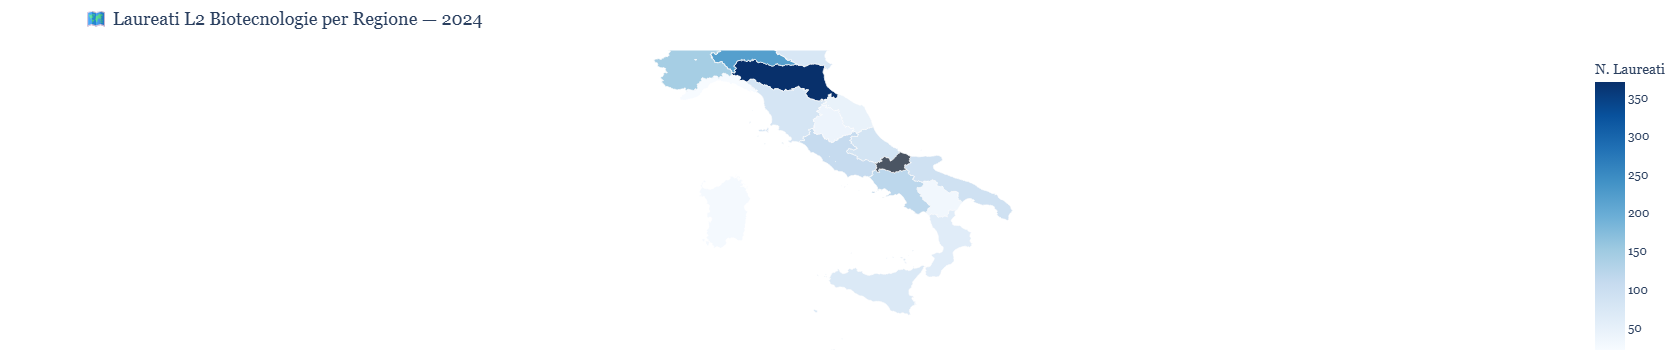

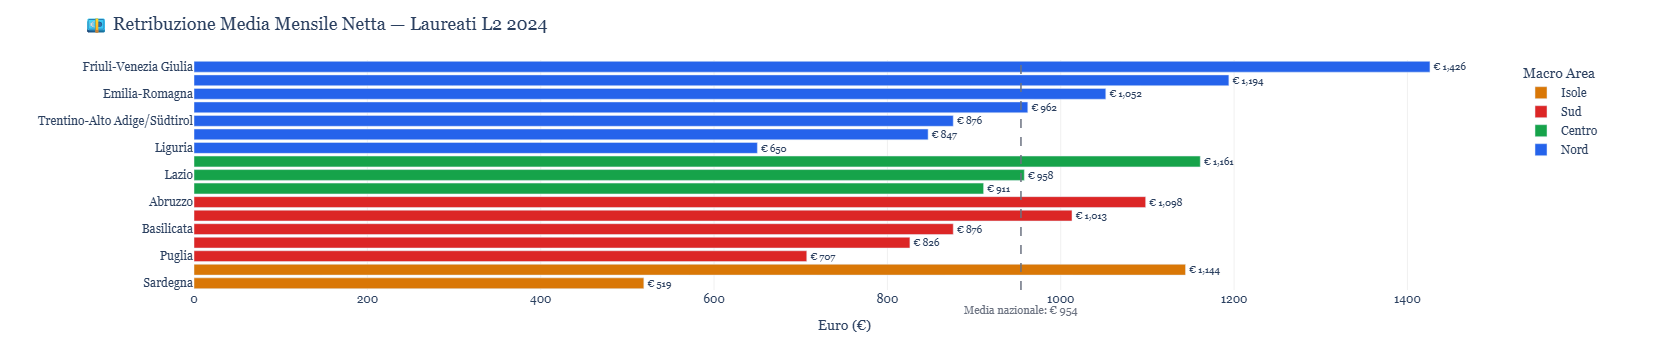

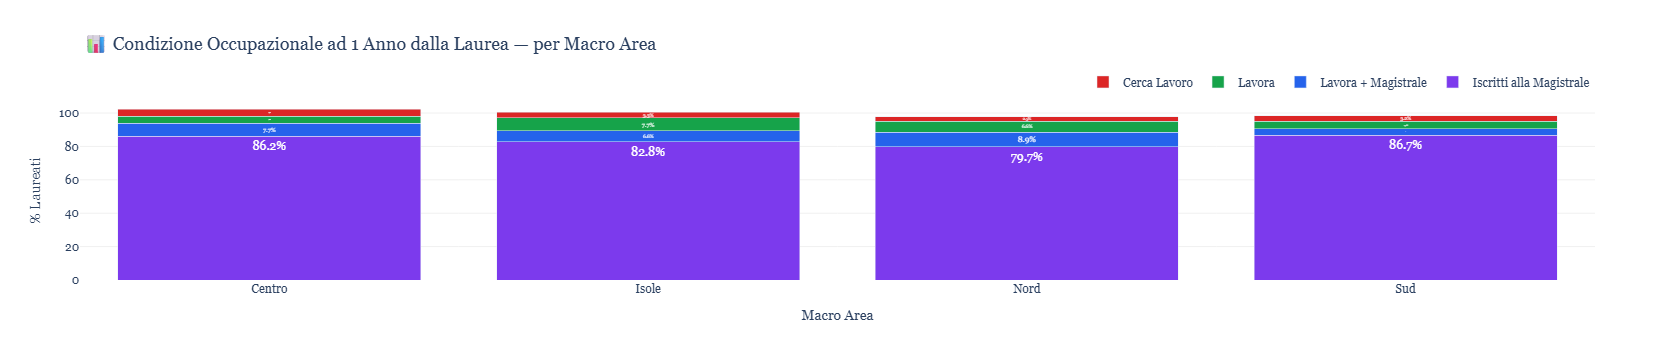

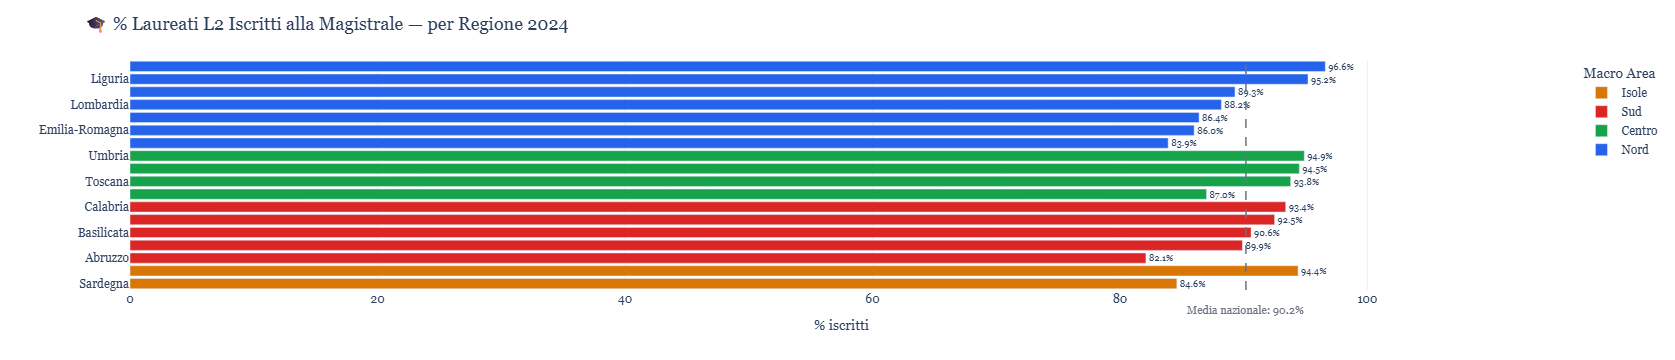

✅ Tutti e 4 i grafici generati!

── Verifica grafico 3 (medie per macro-area) ──
            pct_solo_magistrale  pct_lavorano_e_magistrale  pct_lavorano_solo  pct_cercano_lavoro
macro_area                                                                                       
Centro                     86.2                        7.7                4.2                 4.3
Isole                      82.8                        6.6                7.7                 3.3
Nord                       79.7                        8.9                6.6                 2.5
Sud                        86.7                        3.8                4.7                 3.2


In [12]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# ── CARICA DATI ───────────────────────────────────────────────────────────────

df = pd.read_csv(
    r"C:\Users\Administrator\Desktop\PROGETTO_L2\almalaurea_2024_clean.csv",
    encoding="utf-8-sig"
)

COLORI = {
    "Nord":   "#2563EB",
    "Centro": "#16A34A",
    "Sud":    "#DC2626",
    "Isole":  "#D97706",
}

REGIONE_GEO = {
    "PIEMONTE":   "Piemonte",
    "LIGURIA":    "Liguria",
    "LOMBARDIA":  "Lombardia",
    "TRENTINO":   "Trentino-Alto Adige/Südtirol",
    "VENETO":     "Veneto",
    "FRIULI":     "Friuli-Venezia Giulia",
    "EMILIA":     "Emilia-Romagna",
    "TOSCANA":    "Toscana",
    "UMBRIA":     "Umbria",
    "MARCHE":     "Marche",
    "LAZIO":      "Lazio",
    "ABBRUZZO":   "Abruzzo",
    "ABRUZZO":    "Abruzzo",
    "CAMPANIA":   "Campania",
    "PUGLIA":     "Puglia",
    "BASILICATA": "Basilicata",
    "CALABRIA":   "Calabria",
    "SICILIA":    "Sicilia",
    "SARDEGNA":   "Sardegna",
}

df["reg_name"]      = df["regione"].map(REGIONE_GEO)
df["regione_label"] = df["reg_name"]

GEOJSON_URL = (
    "https://raw.githubusercontent.com/openpolis/geojson-italy/"
    "master/geojson/limits_IT_regions.geojson"
)

# ════════════════════════════════════════════════════════════════════════════════
# GRAFICO 1 — Mappa coropletica con Molise e Valle d'Aosta in grigio
# ════════════════════════════════════════════════════════════════════════════════

# Proviamo entrambe le varianti del nome per Valle d'Aosta
no_corso_nomi = [
    "Valle d'Aosta/Vallée d'Aoste",
    "Molise",
]

fig1 = go.Figure()

# Traccia principale — regioni con corso (scala Blues)
fig1.add_trace(go.Choropleth(
    geojson=GEOJSON_URL,
    locations=df["reg_name"],
    featureidkey="properties.reg_name",
    z=df["n_laureati"],
    colorscale="Blues",
    colorbar=dict(title="N. Laureati", x=1.0),
    marker_line_color="white",
    marker_line_width=1,
    hovertemplate=(
        "<b>%{location}</b><br>"
        "Laureati: %{z:.0f}<br>"
        "<extra></extra>"
    ),
    name="Regioni con L2",
))

# Traccia secondaria — grigio scuro per regioni senza corso
fig1.add_trace(go.Choropleth(
    geojson=GEOJSON_URL,
    locations=no_corso_nomi,
    featureidkey="properties.reg_name",
    z=[0, 0],
    colorscale=[[0, "#4B5563"], [1, "#4B5563"]],
    showscale=False,
    marker_line_color="white",
    marker_line_width=1,
    hovertemplate=(
        "<b>%{location}</b><br>"
        "Nessun corso L2 attivo<br>"
        "<extra></extra>"
    ),
    name="Nessun corso L2",
))

fig1.update_geos(fitbounds="locations", visible=False)
fig1.update_layout(
    title="🗺️ Laureati L2 Biotecnologie per Regione — 2024",
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    height=580,
    font_family="Georgia",
    title_font_size=18,
)
fig1.show()


# ════════════════════════════════════════════════════════════════════════════════
# GRAFICO 2 — Retribuzione media per regione (barre orizzontali)
# ════════════════════════════════════════════════════════════════════════════════

df_ret = (
    df.dropna(subset=["retribuzione_media"])
    .sort_values("retribuzione_media", ascending=True)
)
media_naz = df_ret["retribuzione_media"].mean()

fig2 = go.Figure()

for macro in ["Isole", "Sud", "Centro", "Nord"]:
    subset = df_ret[df_ret["macro_area"] == macro]
    fig2.add_trace(go.Bar(
        x=subset["retribuzione_media"],
        y=subset["regione_label"],
        orientation="h",
        name=macro,
        marker_color=COLORI[macro],
        text=subset["retribuzione_media"].apply(lambda x: f"€ {x:,.0f}"),
        textposition="outside",
        hovertemplate="<b>%{y}</b><br>Retribuzione: € %{x:,.0f}<extra></extra>",
    ))

fig2.add_vline(x=media_naz, line_dash="dash", line_color="#6B7280", line_width=1.5)
fig2.add_annotation(
    x=media_naz, y=-0.12, yref="paper",
    text=f"Media nazionale: € {media_naz:,.0f}",
    showarrow=False,
    font=dict(color="#6B7280", size=11),
    align="center",
)

fig2.update_layout(
    title="💶 Retribuzione Media Mensile Netta — Laureati L2 2024",
    xaxis_title="Euro (€)",
    yaxis_title="",
    barmode="overlay",
    height=560,
    legend_title="Macro Area",
    font_family="Georgia",
    title_font_size=18,
    plot_bgcolor="white",
    xaxis=dict(gridcolor="#f0f0f0"),
    margin=dict(l=130, r=180, t=60, b=70),
)
fig2.show()


# ════════════════════════════════════════════════════════════════════════════════
# GRAFICO 3 — Condizione occupazionale (barre impilate per macro-area)
# ════════════════════════════════════════════════════════════════════════════════

condizioni_candidate = {
    "Iscritti alla Magistrale":  "pct_solo_magistrale",
    "Lavora + Magistrale":       "pct_lavorano_e_magistrale",
    "Lavora":                    "pct_lavorano_solo",
    "Cerca Lavoro":              "pct_cercano_lavoro",
}
condizioni = {k: v for k, v in condizioni_candidate.items() if v in df.columns}

agg = (
    df.groupby("macro_area")[list(condizioni.values())]
    .mean()
    .reset_index()
)

colori_barre = {
    "Iscritti alla Magistrale": "#7C3AED",
    "Lavora + Magistrale":      "#2563EB",
    "Lavora":                   "#16A34A",
    "Cerca Lavoro":             "#DC2626",
}

fig3 = go.Figure()

for label, col in condizioni.items():
    fig3.add_trace(go.Bar(
        name=label,
        x=agg["macro_area"],
        y=agg[col].round(1),
        marker_color=colori_barre[label],
        text=agg[col].round(1).astype(str) + "%",
        textposition="inside",
        hovertemplate=f"<b>{label}</b><br>%{{x}}: %{{y:.1f}}%<extra></extra>",
    ))

fig3.update_layout(
    barmode="stack",
    title="📊 Condizione Occupazionale ad 1 Anno dalla Laurea — per Macro Area",
    xaxis_title="Macro Area",
    yaxis_title="% Laureati",
    height=500,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    font_family="Georgia",
    title_font_size=18,
    plot_bgcolor="white",
    yaxis=dict(gridcolor="#f0f0f0"),
)
fig3.show()


# ════════════════════════════════════════════════════════════════════════════════
# GRAFICO 4 — % iscritti alla magistrale per regione (barre orizzontali)
# ════════════════════════════════════════════════════════════════════════════════

df_mag = (
    df.dropna(subset=["pct_iscritti_magistrale"])
    .sort_values("pct_iscritti_magistrale", ascending=True)
)
media_mag = df_mag["pct_iscritti_magistrale"].mean()

fig4 = go.Figure()

for macro in ["Isole", "Sud", "Centro", "Nord"]:
    subset = df_mag[df_mag["macro_area"] == macro]
    fig4.add_trace(go.Bar(
        x=subset["pct_iscritti_magistrale"],
        y=subset["regione_label"],
        orientation="h",
        name=macro,
        marker_color=COLORI[macro],
        text=subset["pct_iscritti_magistrale"].apply(lambda x: f"{x:.1f}%"),
        textposition="outside",
        hovertemplate="<b>%{y}</b><br>Iscritti magistrale: %{x:.1f}%<extra></extra>",
    ))

fig4.add_vline(x=media_mag, line_dash="dash", line_color="#6B7280", line_width=1.5)
fig4.add_annotation(
    x=media_mag, y=-0.12, yref="paper",
    text=f"Media nazionale: {media_mag:.1f}%",
    showarrow=False,
    font=dict(color="#6B7280", size=11),
    align="center",
)

fig4.update_layout(
    title="🎓 % Laureati L2 Iscritti alla Magistrale — per Regione 2024",
    xaxis_title="% iscritti",
    yaxis_title="",
    height=560,
    legend_title="Macro Area",
    font_family="Georgia",
    title_font_size=18,
    plot_bgcolor="white",
    xaxis=dict(gridcolor="#f0f0f0", range=[0, 115]),
    margin=dict(l=130, r=100, t=60, b=70),
)
fig4.show()


print("✅ Tutti e 4 i grafici generati!")
print()

# Verifica rapida dati grafico 3
print("── Verifica grafico 3 (medie per macro-area) ──")
cols_check = [c for c in condizioni.values() if c in df.columns]
print(df.groupby("macro_area")[cols_check].mean().round(1).to_string())

In [14]:
import shutil
shutil.copy(
    r"C:\Users\Administrator\Downloads\app.py",
    r"C:\Users\Administrator\Desktop\PROGETTO_L2\app.py"
)
print("✅ File copiato!")

✅ File copiato!


In [1]:
import os
print(os.getcwd())

C:\PROGETTO_L2(BioTecnologie)analisi


In [4]:
import os

cartella = r"C:\PROGETTO_L2(BioTecnologie)analisi"

for root, dirs, files in os.walk(cartella):
    livello = root.replace(cartella, '').count(os.sep)
    indent = '  ' * livello
    print(f"{indent}{os.path.basename(root)}/")
    for file in files:
        print(f"{indent}  📄 {file}")

PROGETTO_L2(BioTecnologie)analisi/
  📄 MURiscrittixclasse.csv
  📄 MUR_laureatixclasse.csv
  📄 PROJECT.ipynb
  .ipynb_checkpoints/
    📄 PROJECT-checkpoint.ipynb
  .virtual_documents/
    📄 PROJECT.ipynb
  ALMALAUREA_occupazione/
    📄 almalaurea_2024_clean.csv
    📄 datialmalaurea(1LV_2021)occupazione.csv
    📄 datialmalaurea(1LV_2022)occupazione.csv
    📄 datialmalaurea(1LV_2023)occupazione.csv
    📄 datialmalaurea(1LV_2024)occupazione.csv
    📄 datialmalaurea(L2_2021)occupazione.csv
    📄 datialmalaurea(L2_2022)occupazione.csv
    📄 datialmalaurea(L2_2023)occupazione.csv
    📄 datialmalaurea(L2_2024)occupazione.csv
    📄 datialmalaureaABBRUZZO(occupazione).csv
    📄 datialmalaureaBASILICATA(occupazione).csv
    📄 datialmalaureaCALABRIA(occupazione).csv
    📄 datialmalaureaCAMPANIA(occupazione).csv
    📄 datialmalaureaEMILIA(occupazione).csv
    📄 datialmalaureaFRIULI(occupazione).csv
    📄 datialmalaureaLAZIO(occupazione).csv
    📄 datialmalaureaLIGURIA(occupazione).csv
    📄 datialm

In [6]:
import pandas as pd

cartella = r"C:\PROGETTO_L2(BioTecnologie)analisi\ALMALAUREA_occupazione"

files_da_vedere = [
    "datialmalaurea(L2_2021)occupazione.csv",
    "datialmalaurea(1LV_2021)occupazione.csv",
]

for filename in files_da_vedere:
    filepath = cartella + "\\" + filename
    print(f"\n{'='*60}")
    print(f"FILE: {filename}")
    print('='*60)
    with open(filepath, encoding="latin-1") as f:
        for i, line in enumerate(f):
            if i > 15:
                break
            print(f"Riga {i}: {repr(line.strip())}")


FILE: datialmalaurea(L2_2021)occupazione.csv
Riga 0: '"1. Popolazione analizzata"'
Riga 1: '"";""'
Riga 2: '"Numero di laureati";"1890"'
Riga 3: '"Numero di intervistati";"1890"'
Riga 4: '"Tasso di risposta sul totale dei laureati";"100,0"'
Riga 5: '"Tasso di risposta sui laureati contattabili";"100,0"'
Riga 6: '"Genere (%)";""'
Riga 7: '"Uomini";"29,8"'
Riga 8: '"Donne";"70,2"'
Riga 9: '"Eta\' alla laurea (medie, in anni)";"23,1"'
Riga 10: '"Voto di laurea (medie, in 110-mi)";"101,8"'
Riga 11: '"Durata degli studi (medie, in anni)";"3,7"'
Riga 12: '"Indice di ritardo";"0,24"'
Riga 13: '"2a. Formazione di secondo livello"'
Riga 14: '"";""'
Riga 15: '"Iscrizione, dopo la laurea di primo livello, ad un altro corso di laurea (%)";""'

FILE: datialmalaurea(1LV_2021)occupazione.csv
Riga 0: '"1. Popolazione analizzata"'
Riga 1: '"";""'
Riga 2: '"Numero di laureati";"82978"'
Riga 3: '"Numero di intervistati";"82978"'
Riga 4: '"Tasso di risposta sul totale dei laureati";"100,0"'
Riga 5: '"Tas